# GFC 2007–2009 on the Evergreen_v5 narrative panel: attention post-processing

Reads the production `narrative_daily` artifact scored against the registered **Evergreen_v5**
taxonomy (R2, headline paraphrases, max pooling, q = 0.99, point-in-time tau_asof). The
notebook is **read-only** on the datalake and writes nothing.

**Raw signal θ.** θ_{d,n} = ATTENTION = TOTAL_SCORE / N_HEADLINES: the share of day *d*'s
headline flow that the scorer attributes to narrative *n* (≥ 0; a day where nothing clears
tau has θ = 0, and the two poles of a bipolar narrative are separate series). There is no
signed LLM score here, so the stages below run on attention.

**Post-processing (stages 1–5, all causal / point-in-time):**

| # | stage | definition used here |
|---|---|---|
| 1 | deseasonalise | θ̃_{d,n} = θ_{d,n} − s_{y,w,n}, where s is the **expanding mean over prior ISO years only** of the week-of-year mean (w = ISO week of *d*, week 53 folded into 52). The first year has no prior and is dropped (warm-up). |
| 2 | weekly | θ̄_{t,n} = mean of θ̃ over the Mon–Fri days of ISO week *t*; the week is stamped on its Friday (known at Friday close). |
| 3 | change | Δθ_{t,n} = θ̄_{t,n} − θ̄_{t−1,n} (null across a missing week). |
| 4 | horizon smoothing | Δθ^{(h)}_{t,n} = rolling mean of Δθ over the last *h* weeks (= (θ̄_t − θ̄_{t−h}) / h); short h ∈ 1–12w, long h ∈ 12–52w. |
| 5 | cross-horizon composite | C_{t,n} = (1/\|H\|) Σ_{h∈H} Δθ^{(h)}_{t,n} / σ^{(h)}_t with H = {12, 26, 52} and σ^{(h)}_t the **cross-sectional** std (ddof = 0) of Δθ^{(h)}_{·,t} across narratives. The numerator is **not demeaned**: a crisis that lifts every stress narrative at once shows up as a positive cross-sectional mean. |

The return branches (6a narrative-beta portfolios, 6b narrative-mimicking portfolios) are out
of scope here: this notebook analyses the attention signal itself.

**Analysis:** coverage → stage-by-stage walk-through → seasonality diagnostics → composite
properties → predeclared GFC batteries (time series, heatmaps, event table with a
random-battery permutation test) → horizon term structure → cross-section at Lehman →
narrative waves (onset / peak timing) → robustness to stage 1 → placebo (must-not-fire).

The batteries are **predeclared** (fixed before looking at the composite), using Evergreen_v5
narrative names; a name that exists in several reservoirs contributes every scoped
`narrative_key` it maps to.

In [2]:
import os
from datetime import date, timedelta

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import TwoSlopeNorm
from dotenv import find_dotenv, load_dotenv

from datalake import DatalakeIndex

load_dotenv(find_dotenv(usecwd=True))
pl.Config.set_tbl_rows(40); pl.Config.set_tbl_width_chars(220); pl.Config.set_fmt_str_lengths(60)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.constrained_layout.use": True})

# ---- data -----------------------------------------------------------------------------
TAXONOMY = "Evergreen_v5"
NARRATIVE_DAILY_ID = None        # None = most recent narrative_daily of TAXONOMY (partial allowed)
KEY = "narrative_key"            # scoped reservoir|dimension|narrative(|pole) id

# ---- post-processing ------------------------------------------------------------------
MIN_PRIOR_YEARS = 1              # stage 1: seasonal mean needs >= this many prior years
SHORT_H = (1, 2, 4, 8, 12)       # stage 4, short horizons (weeks)
LONG_H = (12, 26, 52)            # stage 4, long horizons (weeks)
COMPOSITE_H = (12, 26, 52)       # stage 5
ALL_H = tuple(sorted(set(SHORT_H) | set(LONG_H)))

# ---- study windows --------------------------------------------------------------------
VIEW = (date(2005, 1, 1), date(2010, 12, 31))
BASELINE = (date(2004, 7, 1), date(2007, 6, 30))   # pre-crisis reference for z-scores
ONSET_THRESHOLD = 1.0                               # composite level that counts as "lit"
N_PERM = 20_000                                     # random batteries per permutation test
RNG = np.random.default_rng(0)

EVENTS = {
    "BNP funds frozen": date(2007, 8, 9),
    "Northern Rock": date(2007, 9, 14),
    "Bear Stearns": date(2008, 3, 14),
    "GSE conservatorship": date(2008, 9, 7),
    "Lehman": date(2008, 9, 15),
    "TARP signed": date(2008, 10, 3),
    "Coordinated cut": date(2008, 10, 8),
    "NBER recession call": date(2008, 12, 1),
    "Equity trough": date(2009, 3, 9),
    "SCAP results": date(2009, 5, 7),
}
KEY_EVENTS = ("BNP funds frozen", "Bear Stearns", "Lehman", "Equity trough")

BATTERIES = {
    "funding / liquidity": ["funding-squeeze", "repo-and-money-market-dislocation", "liquidity-hoarding",
                            "cross-border-dollar-funding-stress", "collateral-scarcity-and-haircut-stress"],
    "systemic solvency": ["bank-run", "sifi-failure-risk", "systemic-capital-shortfall",
                          "systemic-fragility", "systemic-credit-spread-stress"],
    "contagion": ["contagion-cascade", "counterparty-domino", "cross-market-contagion",
                  "fire-sale-deleveraging-spiral"],
    "bank intermediation": ["bank-balance-sheet-impairment", "credit-crunch-salience",
                            "credit-supply-tightening"],
    "non-bank / MMF": ["money-market-fund-run", "shadow-bank-solvency-scare", "non-bank-deleveraging",
                       "non-bank-channel-stress"],
    "policy response": ["rate-easing-cycle", "balance-sheet-expansion", "liquidity-facility-as-policy",
                        "swap-line-activation", "fiscal-expansion-impulse"],
    "real economy / defaults": ["business-cycle-contraction", "hard-landing", "labour-market-slackening",
                                "default-wave-salience", "default-cycle-deterioration", "credit-contraction"],
    "housing bust": ["housing-bust"],
    "market fear": ["fear-gauge-spike", "risk-off-flight", "flight-to-safety-demand",
                    "capitulation-crash-narrative", "turbulent-market-read"],
    "MUST-NOT-FIRE": ["credit-boom", "housing-boom", "consumption-boom", "benign-credit-environment",
                      "rate-tightening-cycle", "risk-on-appetite", "momentum-melt-up", "complacency-read",
                      "calm-market-read", "credit-supply-expansion", "profit-cycle-upturn",
                      "business-cycle-expansion"],
}
PLACEBO = "MUST-NOT-FIRE"
SHOWCASE = "funding-squeeze"     # narrative used for the stage-by-stage walk-through


def shade_events(ax, which=KEY_EVENTS, labels=True):
    # vertical event lines on a date axis
    ymax = ax.get_ylim()[1]
    for name in which:
        d = EVENTS[name]
        ax.axvline(d, color="0.35", lw=0.8, ls="--", zorder=0)
        if labels:
            ax.text(d, ymax, f" {name}", rotation=90, va="top", ha="right", fontsize=7, color="0.3")


def date_axis(ax, lo=VIEW[0], hi=VIEW[1]):
    ax.set_xlim(lo, hi)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

## 1. Data: the Evergreen_v5 `narrative_daily` panel

The artifact may still be `partial` while the scoring job runs; every month file present is a
completed month. Only the `SENTIMENT == "all"` rows are used (attention, no sentiment split).

In [3]:
dl = DatalakeIndex(os.environ["DATALAKE_ROOT"], create=False)
if NARRATIVE_DAILY_ID is not None:
    ART = dl.get(NARRATIVE_DAILY_ID)
else:
    cands = [a for a in dl.list("narrative_daily", include_partial=True)
             if a.meta.hyperparams.get("taxonomy_name") == TAXONOMY and not a.deprecated]
    if not cands:
        raise LookupError(f"no narrative_daily artifact for taxonomy {TAXONOMY!r}")
    ART = cands[0]
hp = ART.meta.hyperparams
print(ART.artifact_id, "| partial:", ART.partial)
print({k: hp.get(k) for k in ("taxonomy_name", "taxonomy_artifact_id", "mode", "pooling",
                              "paraphrase_style", "q", "split", "window", "config_id")})
FILES = sorted(ART.path.glob("[12][0-9][0-9][0-9]-[01][0-9].parquet"))
print(f"{len(FILES)} month files: {FILES[0].stem} .. {FILES[-1].stem}")

narrative_daily__v2.2.0__params0a029753__20260927 | partial: False
{'taxonomy_name': 'Evergreen_v5', 'taxonomy_artifact_id': 'narrative_taxonomy__v2.1.0__paramsbf25ede9__20260923', 'mode': 'r2', 'pooling': 'max', 'paraphrase_style': 'headline', 'q': 0.99, 'split': 'none', 'window': '5Y', 'config_id': '9de874ad4aaa9d3e'}
309 month files: 2000-04 .. 2025-12


In [4]:
def load_attention(files) -> pl.DataFrame:
    # daily (DATE x narrative_key) attention; THETA is null only when the day has no headlines
    return (
        pl.scan_parquet([str(f) for f in files])
        .filter(pl.col("SENTIMENT") == "all")
        .select("DATE", "reservoir", "dimension", "narrative", "pole", KEY,
                "SUPPORT", "TOTAL_SCORE", "N_HEADLINES")
        .with_columns(
            pl.when(pl.col("N_HEADLINES") > 0)
            .then(pl.col("TOTAL_SCORE").fill_null(0.0) / pl.col("N_HEADLINES"))
            .otherwise(None).alias("THETA"))
        .sort(KEY, "DATE")
        .collect()
    )


daily = load_attention(FILES)
NARR = daily.select("reservoir", "dimension", "narrative", "pole", KEY).unique(KEY).sort(KEY)
print(f"{daily.height:,} rows | {daily['DATE'].n_unique():,} days | {NARR.height} narrative keys | "
      f"{daily['DATE'].min()} .. {daily['DATE'].max()}")
dup = daily.group_by("DATE", KEY).len().filter(pl.col("len") > 1).height
assert dup == 0, f"{dup} duplicated (DATE, {KEY}) rows"

3,941,114 rows | 9,406 days | 419 narrative keys | 2000-04-01 .. 2025-12-31


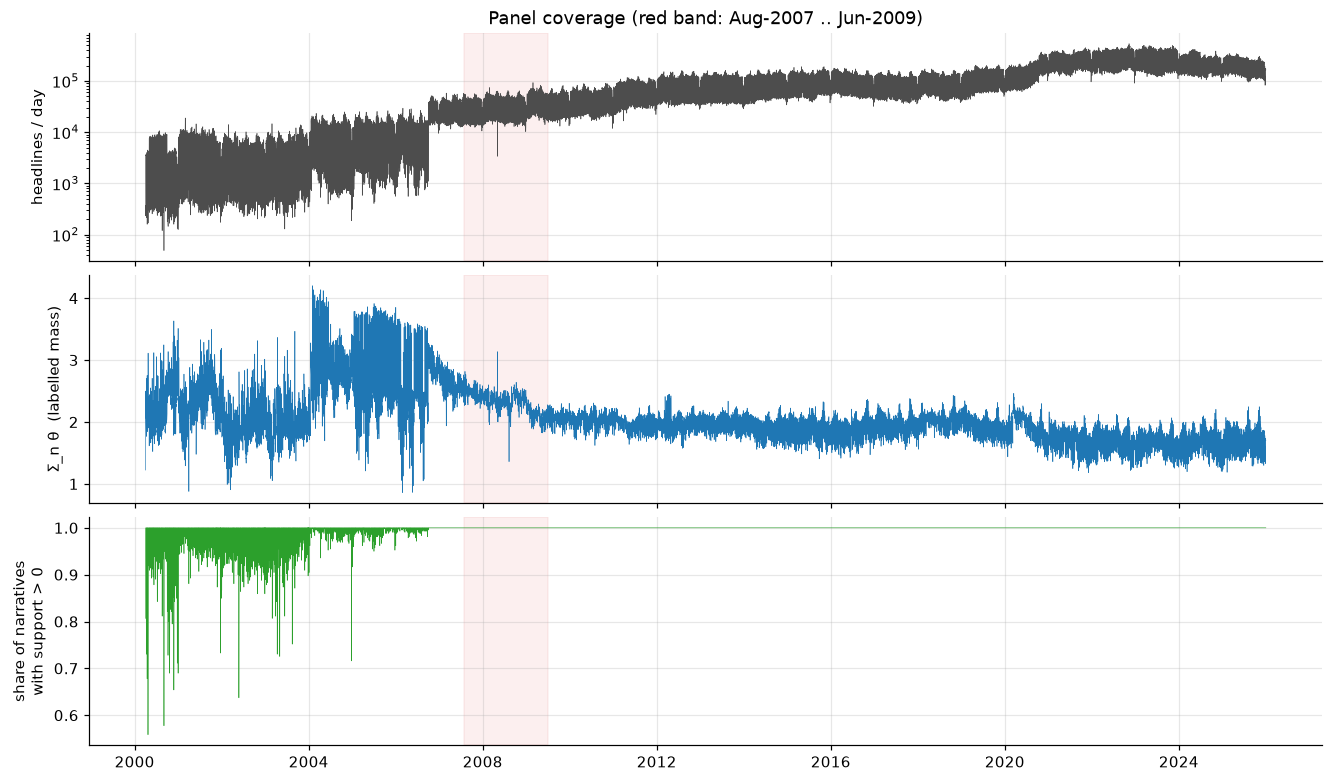

In [5]:
flow = (daily.group_by("DATE").agg(pl.col("N_HEADLINES").first(), pl.col("THETA").sum().alias("SUM_THETA"),
                                   (pl.col("SUPPORT") > 0).mean().alias("SHARE_ACTIVE"))
        .sort("DATE"))
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
axes[0].plot(flow["DATE"], flow["N_HEADLINES"], lw=0.4, color="0.3")
axes[0].set_ylabel("headlines / day"); axes[0].set_yscale("log")
axes[1].plot(flow["DATE"], flow["SUM_THETA"], lw=0.4, color="tab:blue")
axes[1].set_ylabel("Σ_n θ  (labelled mass)")
axes[2].plot(flow["DATE"], flow["SHARE_ACTIVE"], lw=0.4, color="tab:green")
axes[2].set_ylabel("share of narratives\nwith support > 0")
for ax in axes:
    ax.axvspan(date(2007, 8, 1), date(2009, 6, 30), color="tab:red", alpha=0.07)
axes[0].set_title("Panel coverage (red band: Aug-2007 .. Jun-2009)")
plt.show()

## 2. Post-processing pipeline (stages 1–5)

Everything is computed on the long panel keyed by `narrative_key`, per narrative, with only
past information at each step: the seasonal mean of year *y* uses years < *y*; weekly values
are stamped on the Friday; differences and rolling means look backward; the cross-sectional
σ of week *t* uses week-*t* values only.

In [6]:
def deseasonalise(daily: pl.DataFrame, min_prior_years: int = MIN_PRIOR_YEARS) -> pl.DataFrame:
    # stage 1: subtract the expanding, prior-years-only week-of-year mean
    d = daily.with_columns(pl.col("DATE").dt.iso_year().alias("YEAR"),
                           pl.col("DATE").dt.week().clip(1, 52).alias("WOY"))
    yw = (d.group_by(KEY, "YEAR", "WOY").agg(pl.col("THETA").mean().alias("YW_MEAN"))
          .sort(KEY, "WOY", "YEAR")
          .with_columns(pl.col("YW_MEAN").is_not_null().cast(pl.Int32).alias("_has"))
          .with_columns(
              pl.col("YW_MEAN").fill_null(0.0).cum_sum().shift(1).over(KEY, "WOY").alias("_psum"),
              pl.col("_has").cum_sum().shift(1).over(KEY, "WOY").alias("N_PRIOR_YEARS"))
          .with_columns(
              pl.when(pl.col("N_PRIOR_YEARS") >= min_prior_years)
              .then(pl.col("_psum") / pl.col("N_PRIOR_YEARS")).otherwise(None).alias("SEAS"))
          .select(KEY, "YEAR", "WOY", "SEAS", "N_PRIOR_YEARS"))
    return (d.join(yw, on=[KEY, "YEAR", "WOY"], how="left")
            .with_columns((pl.col("THETA") - pl.col("SEAS")).alias("THETA_DS")))


def weekly(d: pl.DataFrame) -> pl.DataFrame:
    # stage 2: Mon-Fri mean, stamped on the Friday, on a complete (week x narrative) grid
    w = (d.filter(pl.col("DATE").dt.weekday() <= 5)
         .with_columns((pl.col("DATE").dt.truncate("1w") + timedelta(days=4)).alias("WEEK"))
         .group_by(KEY, "WEEK")
         .agg(pl.col("THETA_DS").mean().alias("THETA_W"), pl.col("THETA").mean().alias("THETA_RAW_W"),
              pl.col("THETA").count().alias("N_DAYS")))
    lo, hi = w["WEEK"].min(), w["WEEK"].max()
    grid = pl.DataFrame({"WEEK": pl.date_range(lo, hi, "1w", eager=True)}).join(
        w.select(KEY).unique(), how="cross")
    return grid.join(w, on=[KEY, "WEEK"], how="left").sort(KEY, "WEEK")


def changes_and_horizons(w: pl.DataFrame, value: str = "THETA_W", horizons=ALL_H) -> pl.DataFrame:
    # stage 3 (first difference) + stage 4 (backward rolling mean over h weeks, full windows only)
    w = w.with_columns(pl.col(value).diff().over(KEY).alias("DTHETA"))
    return w.with_columns([pl.col("DTHETA").rolling_mean(h, min_samples=h).over(KEY).alias(f"D{h}")
                           for h in horizons])


def composite(w: pl.DataFrame, horizons=COMPOSITE_H, all_h=ALL_H) -> pl.DataFrame:
    # stage 5: each horizon / its own cross-sectional std (ddof=0, NOT demeaned), averaged over H
    w = w.with_columns([(pl.col(f"D{h}") / pl.col(f"D{h}").std(ddof=0).over("WEEK")).alias(f"Z{h}")
                        for h in all_h])
    z = [pl.col(f"Z{h}") for h in horizons]
    complete = pl.all_horizontal([c.is_not_null() & c.is_finite() for c in z])
    return w.with_columns(pl.when(complete).then(pl.sum_horizontal(z) / len(z))
                          .otherwise(None).alias("COMPOSITE"))


def post_process(daily: pl.DataFrame, deseason: bool = True) -> pl.DataFrame:
    d = deseasonalise(daily) if deseason else daily.with_columns(pl.col("THETA").alias("THETA_DS"))
    return composite(changes_and_horizons(weekly(d)))


daily_ds = deseasonalise(daily)
panel = composite(changes_and_horizons(weekly(daily_ds)))
first_valid = panel.filter(pl.col("COMPOSITE").is_not_null())["WEEK"].min()
print(f"{panel.height:,} (week x narrative) rows | weeks {panel['WEEK'].min()} .. {panel['WEEK'].max()}")
print(f"first week with a composite: {first_valid}  "
      f"(1 prior year for stage 1 + 1 week for stage 3 + 52 weeks for the longest horizon)")

563,136 (week x narrative) rows | weeks 2000-04-07 .. 2026-01-02
first week with a composite: 2002-03-29  (1 prior year for stage 1 + 1 week for stage 3 + 52 weeks for the longest horizon)


In [7]:
# sanity checks on the construction
cs = panel.filter(pl.col("COMPOSITE").is_not_null())
for h in COMPOSITE_H:   # each Z^(h) has cross-sectional std exactly 1 by construction
    s = cs.group_by("WEEK").agg(pl.col(f"Z{h}").std(ddof=0))[f"Z{h}"]
    assert np.allclose(s.to_numpy(), 1.0, atol=1e-6), h
chk = panel.filter(pl.col(KEY) == panel[KEY][0]).sort("WEEK").with_columns(
    ((pl.col("THETA_W") - pl.col("THETA_W").shift(12)) / 12).alias("_tel"))
assert np.allclose(chk["D12"].to_numpy(), chk["_tel"].to_numpy(), equal_nan=True, atol=1e-12)
print("σ^(h)-normalisation and the D^(h) = (θ̄_t − θ̄_{t−h})/h telescoping identity hold.")
print("\nweekly days per week:", panel.group_by("WEEK").agg(pl.col("N_DAYS").max())["N_DAYS"]
      .value_counts().sort("N_DAYS").to_dicts())

σ^(h)-normalisation and the D^(h) = (θ̄_t − θ̄_{t−h})/h telescoping identity hold.

weekly days per week: [{'N_DAYS': 3, 'count': 1}, {'N_DAYS': 5, 'count': 1343}]


### 2.1 Stage-by-stage walk-through on one narrative

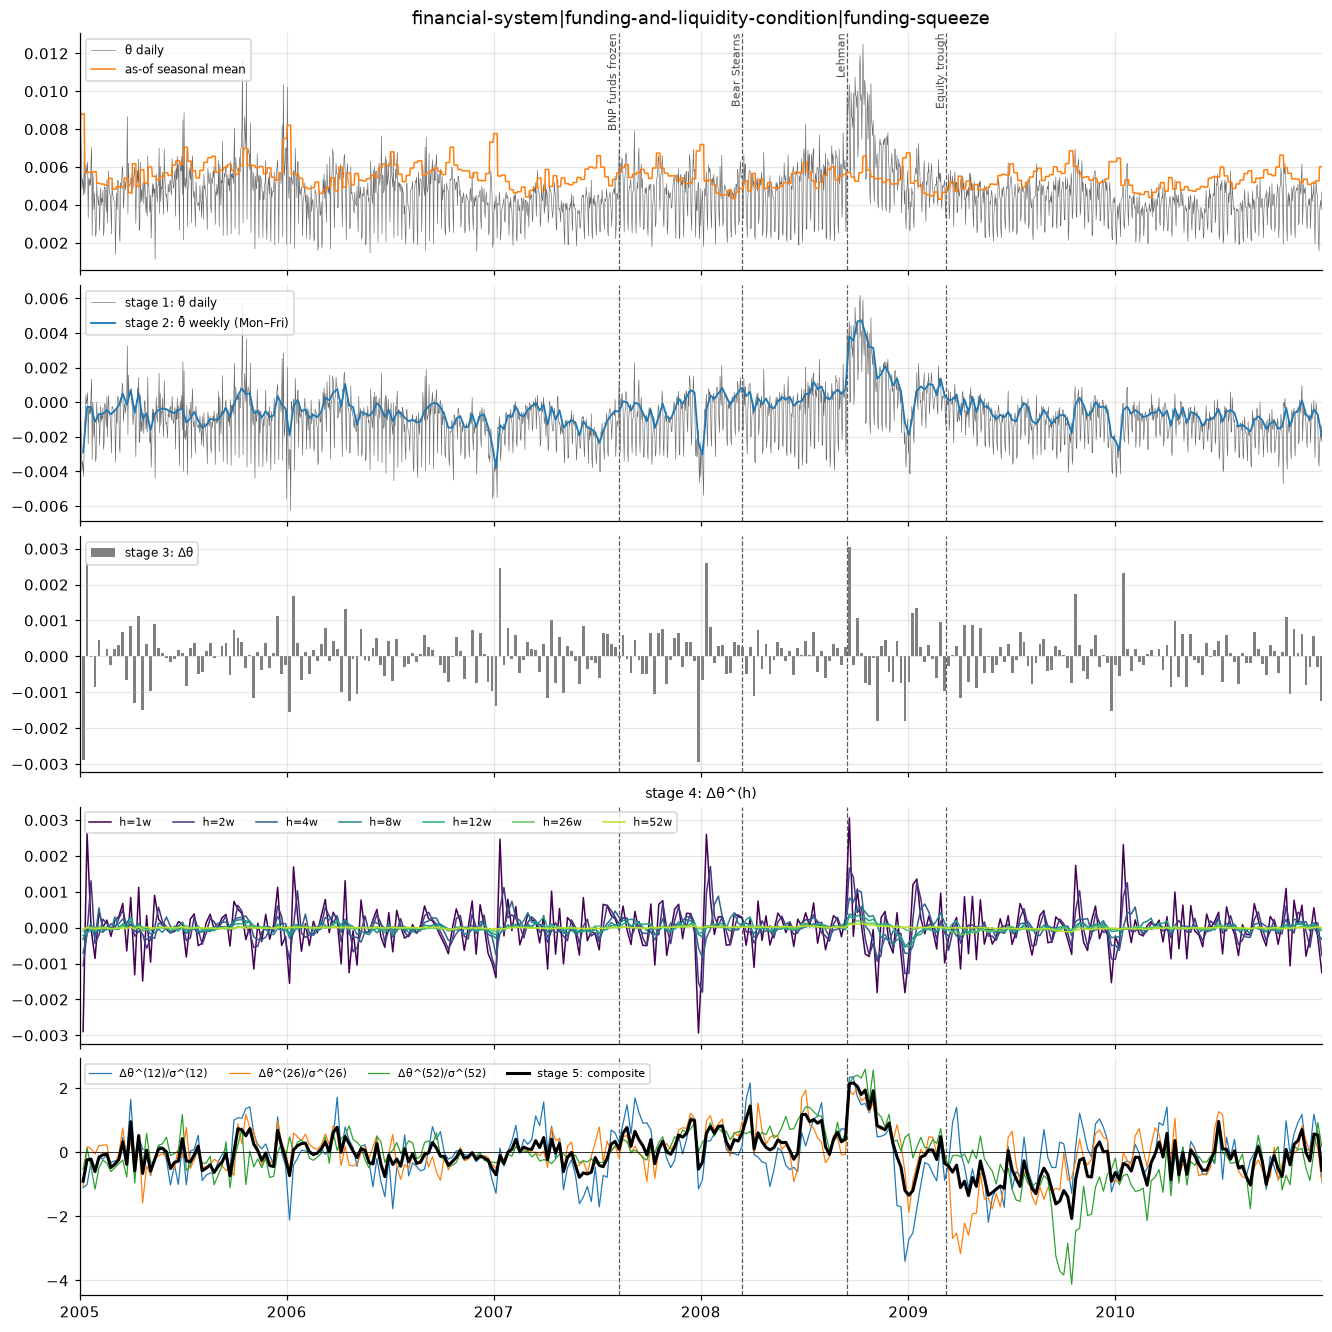

In [8]:
keys = NARR.filter(pl.col("narrative") == SHOWCASE)[KEY].to_list()
assert keys, f"{SHOWCASE!r} not in the panel"
k0 = keys[0]
dd = daily_ds.filter((pl.col(KEY) == k0) & pl.col("DATE").is_between(*VIEW))
pp = panel.filter((pl.col(KEY) == k0) & pl.col("WEEK").is_between(*VIEW))

fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)
axes[0].plot(dd["DATE"], dd["THETA"], lw=0.4, color="0.4", label="θ daily")
axes[0].plot(dd["DATE"], dd["SEAS"], lw=1.0, color="tab:orange", label="as-of seasonal mean")
axes[0].set_title(f"{k0}"); axes[0].legend(loc="upper left", fontsize=8)
axes[1].plot(dd["DATE"], dd["THETA_DS"], lw=0.4, color="0.4", label="stage 1: θ̃ daily")
axes[1].plot(pp["WEEK"], pp["THETA_W"], lw=1.2, color="tab:blue", label="stage 2: θ̄ weekly (Mon–Fri)")
axes[1].legend(loc="upper left", fontsize=8)
axes[2].bar(pp["WEEK"], pp["DTHETA"], width=5, color="0.5", label="stage 3: Δθ")
axes[2].legend(loc="upper left", fontsize=8)
for h, c in zip(ALL_H, plt.cm.viridis(np.linspace(0, 0.9, len(ALL_H)))):
    axes[3].plot(pp["WEEK"], pp[f"D{h}"], lw=1.0, color=c, label=f"h={h}w")
axes[3].set_title("stage 4: Δθ^(h)", fontsize=9); axes[3].legend(ncol=len(ALL_H), fontsize=7, loc="upper left")
for h in COMPOSITE_H:
    axes[4].plot(pp["WEEK"], pp[f"Z{h}"], lw=0.8, label=f"Δθ^({h})/σ^({h})")
axes[4].plot(pp["WEEK"], pp["COMPOSITE"], lw=2.0, color="k", label="stage 5: composite")
axes[4].axhline(0, color="k", lw=0.5); axes[4].legend(ncol=4, fontsize=7, loc="upper left")
for ax in axes:
    date_axis(ax); shade_events(ax, labels=ax is axes[0])
plt.show()

## 3. Seasonality diagnostics (why stage 1)

Share of each narrative's weekly-attention variance explained by week-of-year dummies, on the
pre-crisis sample (raw weekly θ, before stage 1), and the as-of seasonal profile of the most
seasonal narratives. Year-end/holiday weeks and scheduled-release narratives (earnings season,
policy calendars) are the usual culprits.

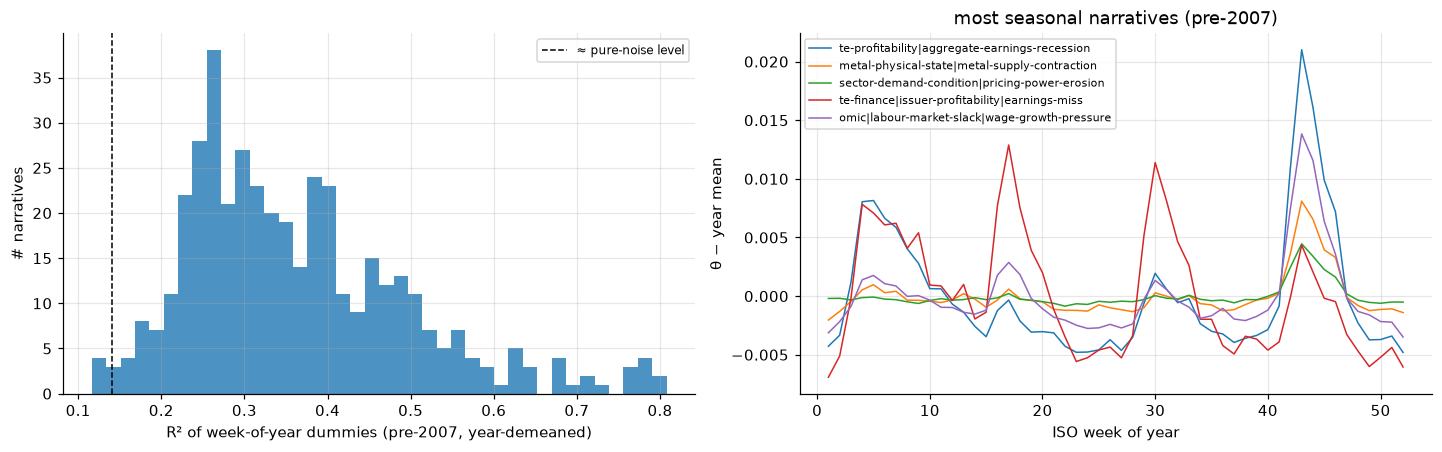

narrative_key,R2_WOY
str,f64
"""macroeconomic|aggregate-corporate-profitability|aggregate-ea…",0.807842
"""commodities|precious-metal-physical-state|metal-supply-contr…",0.797868
"""corporate-finance|issuer-profitability|earnings-miss""",0.788994
"""macroeconomic|labour-market-slack|wage-growth-pressure""",0.781569
"""industry|sector-demand-condition|pricing-power-erosion""",0.780292
"""macroeconomic|aggregate-corporate-profitability|profit-cycle…",0.779634
"""macroeconomic|aggregate-output-and-cycle|productivity-slowdo…",0.771961
"""macroeconomic|aggregate-corporate-profitability|margin-compr…",0.76875
"""corporate-finance|issuer-profitability|earnings-beat""",0.758874


In [9]:
w_raw = (daily.filter(pl.col("DATE").dt.weekday() <= 5)
         .with_columns(pl.col("DATE").dt.iso_year().alias("YEAR"), pl.col("DATE").dt.week().clip(1, 52).alias("WOY"))
         .group_by(KEY, "YEAR", "WOY").agg(pl.col("THETA").mean())
         .filter(pl.col("YEAR") < 2007))
# between-week-of-year share of variance, after removing each year's level (so trend is not "seasonality")
w_raw = w_raw.with_columns((pl.col("THETA") - pl.col("THETA").mean().over(KEY, "YEAR")).alias("X"))
r2 = (w_raw.with_columns(pl.col("X").mean().over(KEY, "WOY").alias("FIT"))
      .group_by(KEY).agg((pl.col("FIT").var() / pl.col("X").var()).alias("R2_WOY"))
      .join(NARR, on=KEY).sort("R2_WOY", descending=True))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(r2["R2_WOY"].drop_nulls(), bins=40, color="tab:blue", alpha=0.8)
n_years = w_raw["YEAR"].n_unique()
axes[0].axvline(51 / (52 * n_years - 1), color="k", ls="--", lw=1, label="≈ pure-noise level")
axes[0].set_xlabel("R² of week-of-year dummies (pre-2007, year-demeaned)"); axes[0].set_ylabel("# narratives")
axes[0].legend(fontsize=8)
prof = (w_raw.filter(pl.col(KEY).is_in(r2.head(5)[KEY].to_list()))
        .group_by(KEY, "WOY").agg(pl.col("X").mean()).sort("WOY"))
for k, g in prof.group_by(KEY, maintain_order=True):
    axes[1].plot(g["WOY"], g["X"], lw=1, label=k[0][-45:])
axes[1].set_xlabel("ISO week of year"); axes[1].set_ylabel("θ − year mean"); axes[1].legend(fontsize=7)
axes[1].set_title("most seasonal narratives (pre-2007)")
plt.show()
r2.select(KEY, "R2_WOY").head(12)

## 4. Properties of the composite

Because the numerator is not demeaned, the cross-sectional **mean** of C_t is itself a
signal: a broad-based rise in attention to "new" narratives (and away from the steady ones).
Breadth = share of narratives with C > 0. The cross-sectional std of C is < 1 whenever the
horizons disagree.

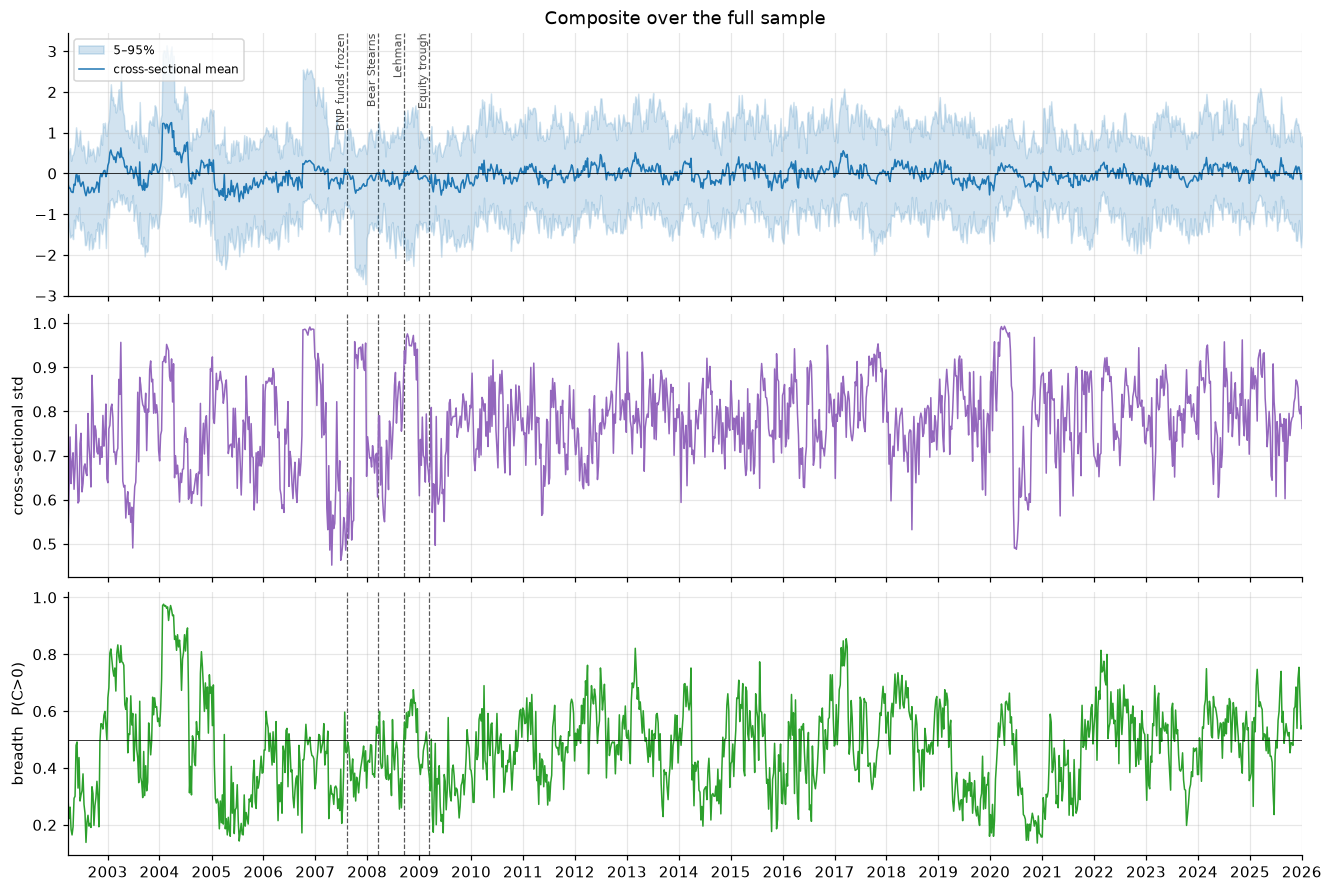

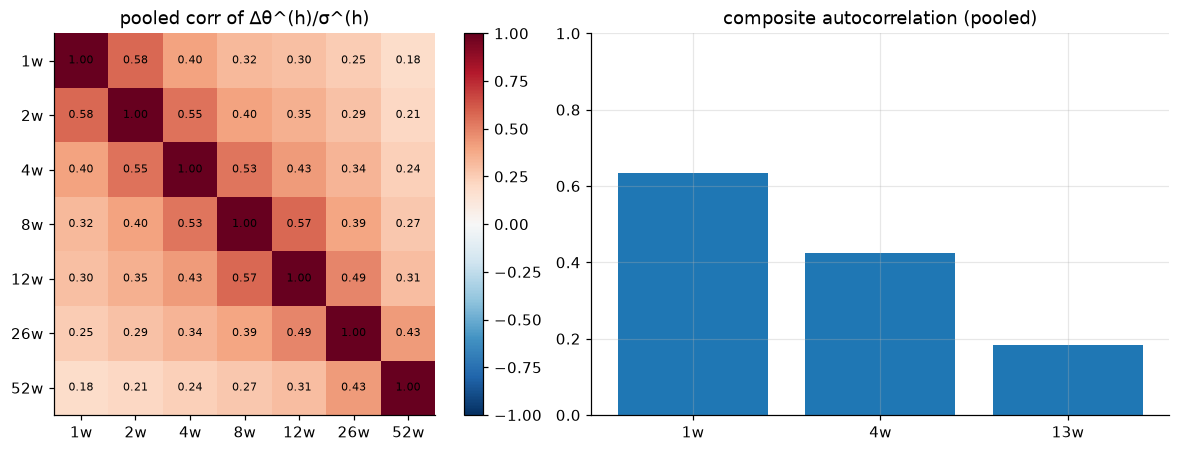

In [10]:
xs = (panel.filter(pl.col("COMPOSITE").is_not_null()).group_by("WEEK")
      .agg(pl.col("COMPOSITE").mean().alias("MEAN"), pl.col("COMPOSITE").std(ddof=0).alias("STD"),
           (pl.col("COMPOSITE") > 0).mean().alias("BREADTH"),
           pl.col("COMPOSITE").quantile(0.95).alias("Q95"), pl.col("COMPOSITE").quantile(0.05).alias("Q05"))
      .sort("WEEK"))
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].fill_between(xs["WEEK"], xs["Q05"], xs["Q95"], color="tab:blue", alpha=0.2, label="5–95%")
axes[0].plot(xs["WEEK"], xs["MEAN"], color="tab:blue", lw=1, label="cross-sectional mean")
axes[0].axhline(0, color="k", lw=0.5); axes[0].legend(fontsize=8, loc="upper left")
axes[1].plot(xs["WEEK"], xs["STD"], color="tab:purple", lw=1); axes[1].set_ylabel("cross-sectional std")
axes[2].plot(xs["WEEK"], xs["BREADTH"], color="tab:green", lw=1); axes[2].axhline(0.5, color="k", lw=0.5)
axes[2].set_ylabel("breadth  P(C>0)")
for ax in axes:
    date_axis(ax, xs["WEEK"].min(), xs["WEEK"].max()); shade_events(ax, labels=ax is axes[0])
axes[0].set_title("Composite over the full sample")
plt.show()

# horizon correlation (pooled, per-week cross-sections) and persistence
zc = panel.select([f"Z{h}" for h in ALL_H]).drop_nulls().to_numpy()
corr = np.corrcoef(zc.T)
ac = (panel.filter(pl.col("COMPOSITE").is_not_null()).sort(KEY, "WEEK")
      .with_columns(pl.col("COMPOSITE").shift(1).over(KEY).alias("L1"),
                    pl.col("COMPOSITE").shift(4).over(KEY).alias("L4"),
                    pl.col("COMPOSITE").shift(13).over(KEY).alias("L13")).drop_nulls(["L1", "L4", "L13"]))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im = axes[0].imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_xticks(range(len(ALL_H)), [f"{h}w" for h in ALL_H]); axes[0].set_yticks(range(len(ALL_H)), [f"{h}w" for h in ALL_H])
for i in range(len(ALL_H)):
    for j in range(len(ALL_H)):
        axes[0].text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=7)
axes[0].set_title("pooled corr of Δθ^(h)/σ^(h)"); axes[0].grid(False); fig.colorbar(im, ax=axes[0])
lags = {"1w": "L1", "4w": "L4", "13w": "L13"}
axes[1].bar(list(lags), [np.corrcoef(ac["COMPOSITE"], ac[c])[0, 1] for c in lags.values()], color="tab:blue")
axes[1].set_title("composite autocorrelation (pooled)"); axes[1].set_ylim(0, 1)
plt.show()

## 5. Predeclared GFC batteries

A battery's composite is the equal-weight mean of C over its narrative keys. The baseline
z-score uses the battery's own weekly composite over the pre-crisis baseline window.

In [11]:
name_to_keys = {n: g[KEY].to_list() for (n,), g in NARR.group_by("narrative")}
BKEYS = {}
for b, names in BATTERIES.items():
    missing = [n for n in names if n not in name_to_keys]
    if missing:
        print(f"[{b}] names not in the taxonomy: {missing}")
    BKEYS[b] = [k for n in names for k in name_to_keys.get(n, [])]
print({b: len(k) for b, k in BKEYS.items()})

wide = (panel.filter(pl.col("COMPOSITE").is_not_null())
        .pivot(on=KEY, index="WEEK", values="COMPOSITE").sort("WEEK"))
WEEKS = wide["WEEK"]
C = wide.drop("WEEK")                     # weeks x narrative keys
CKEYS = C.columns
Cn = C.to_numpy()
bat = pl.DataFrame({"WEEK": WEEKS, **{b: np.nanmean(C.select(k).to_numpy(), axis=1) for b, k in BKEYS.items() if k}})
base = bat.filter(pl.col("WEEK").is_between(*BASELINE))
batz = bat.with_columns([((pl.col(b) - base[b].mean()) / base[b].std()).alias(b) for b in BKEYS if b in bat.columns])
print(f"baseline {BASELINE[0]} .. {BASELINE[1]}: {base.height} weeks")

{'funding / liquidity': 5, 'systemic solvency': 5, 'contagion': 4, 'bank intermediation': 3, 'non-bank / MMF': 4, 'policy response': 5, 'real economy / defaults': 6, 'housing bust': 1, 'market fear': 5, 'MUST-NOT-FIRE': 12}
baseline 2004-07-01 .. 2007-06-30: 157 weeks


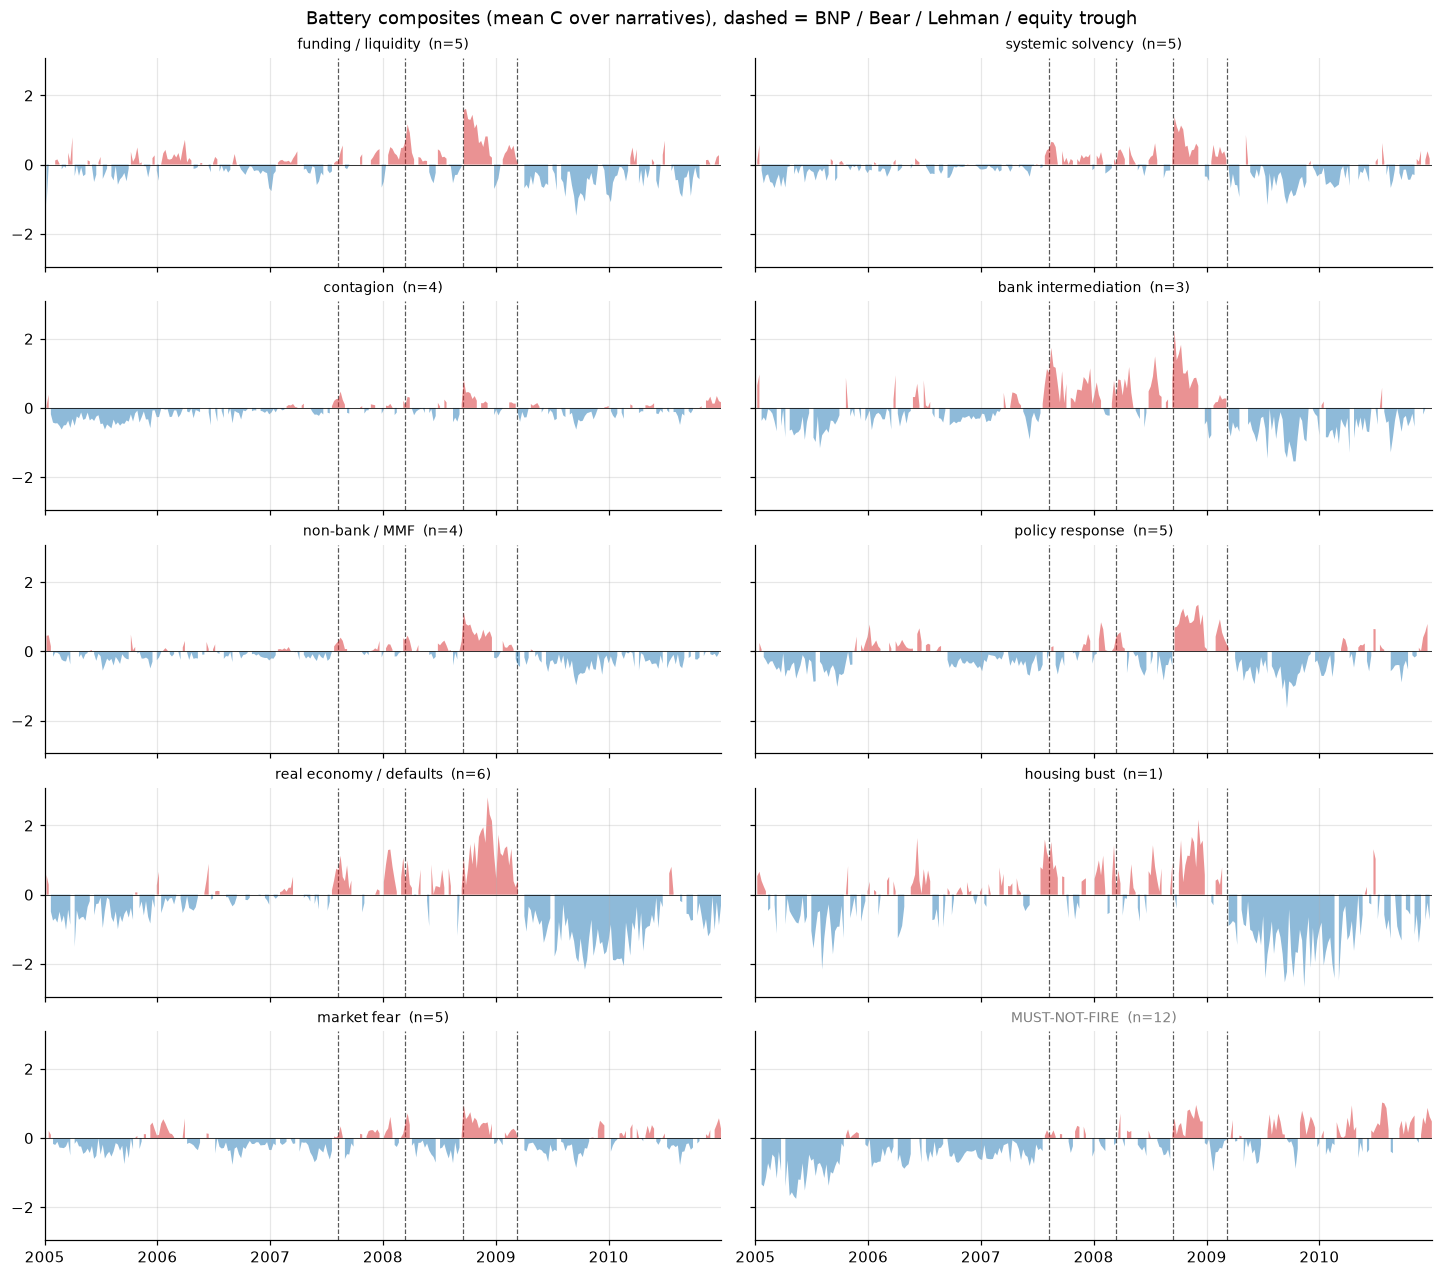

In [12]:
blist = [b for b in BKEYS if b in bat.columns]
ncol = 2
nrow = int(np.ceil(len(blist) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 2.3 * nrow), sharex=True, sharey=True)
v = bat.filter(pl.col("WEEK").is_between(*VIEW))
for ax, b in zip(axes.flat, blist):
    y = v[b].to_numpy()
    ax.fill_between(v["WEEK"], 0, y, where=y > 0, color="tab:red", alpha=0.5, lw=0)
    ax.fill_between(v["WEEK"], 0, y, where=y < 0, color="tab:blue", alpha=0.5, lw=0)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"{b}  (n={len(BKEYS[b])})", fontsize=9, color="tab:gray" if b == PLACEBO else "k")
    date_axis(ax)
for ax in axes.flat[len(blist):]:
    ax.axis("off")
for ax in axes.flat[:len(blist)]:
    shade_events(ax, labels=False)
fig.suptitle("Battery composites (mean C over narratives), dashed = BNP / Bear / Lehman / equity trough")
plt.show()

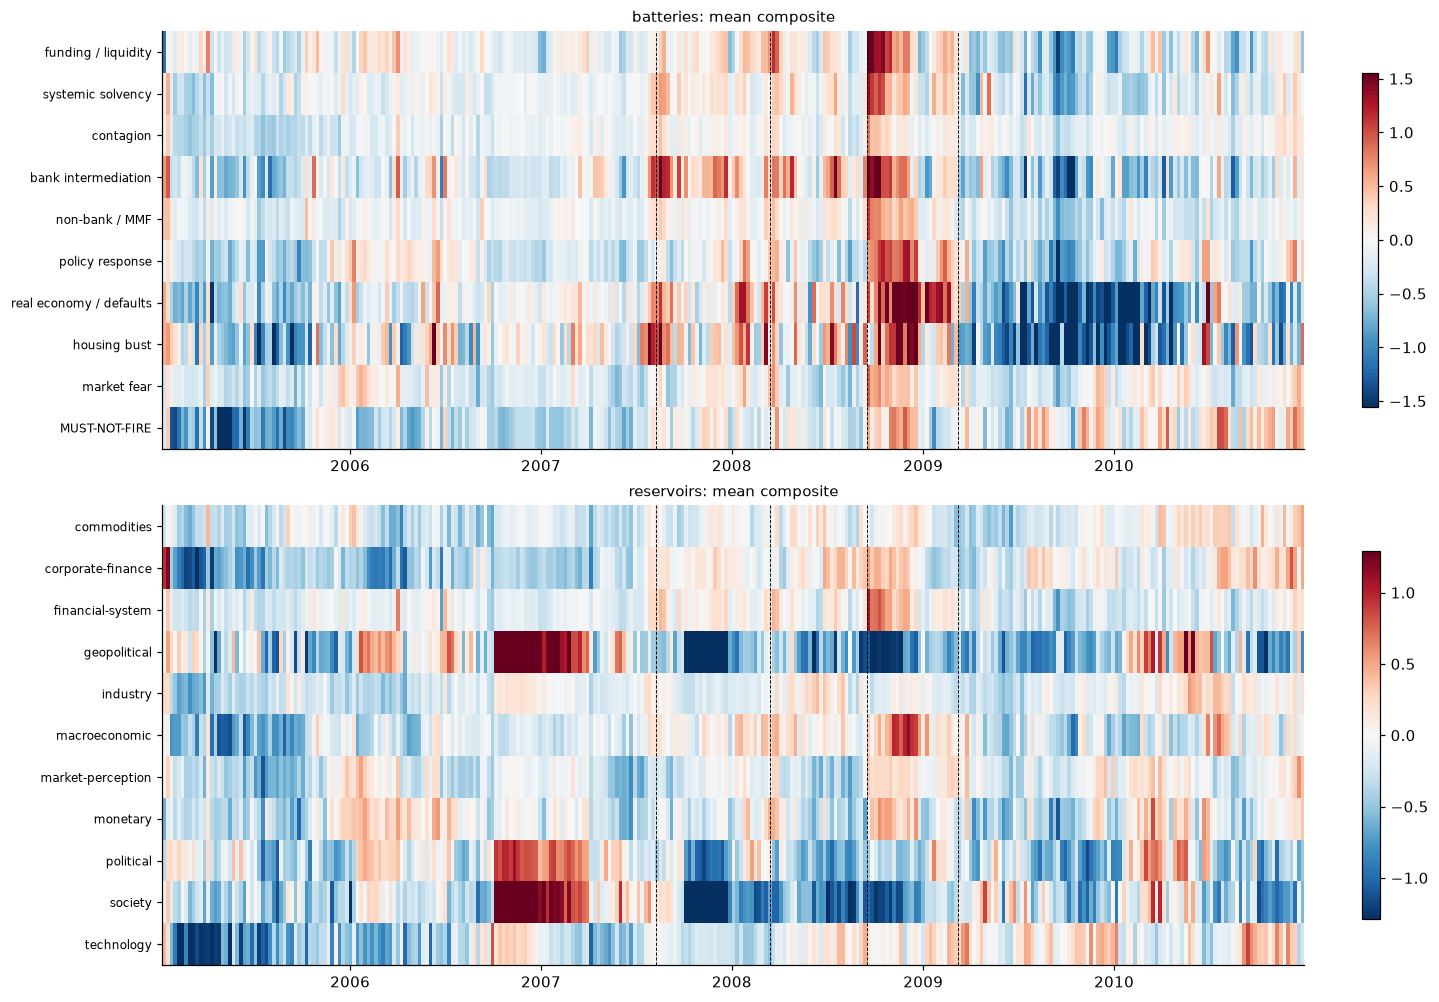

In [13]:
def heat(ax, frame, rows, title, vmax=None):
    m = frame.select(rows).to_numpy().T
    vmax = vmax or np.nanpercentile(np.abs(m), 98)
    x = mdates.date2num(frame["WEEK"].to_list())
    im = ax.imshow(m, aspect="auto", cmap="RdBu_r", norm=TwoSlopeNorm(0, -vmax, vmax),
                   extent=[x[0], x[-1], len(rows) - 0.5, -0.5], interpolation="nearest")
    ax.set_yticks(range(len(rows)), rows, fontsize=8); ax.xaxis_date(); ax.grid(False)
    for name in KEY_EVENTS:
        ax.axvline(EVENTS[name], color="k", lw=0.6, ls="--")
    ax.set_title(title, fontsize=10)
    return im


# reservoir-level mean composite
res = (panel.filter(pl.col("COMPOSITE").is_not_null() & pl.col("WEEK").is_between(*VIEW))
       .join(NARR.select(KEY, "reservoir"), on=KEY)
       .group_by("WEEK", "reservoir").agg(pl.col("COMPOSITE").mean())
       .pivot(on="reservoir", index="WEEK", values="COMPOSITE").sort("WEEK"))
fig, axes = plt.subplots(2, 1, figsize=(13, 9), height_ratios=[len(blist), res.width - 1])
fig.colorbar(heat(axes[0], v, blist, "batteries: mean composite"), ax=axes[0], shrink=0.8)
fig.colorbar(heat(axes[1], res, sorted(res.columns[1:]), "reservoirs: mean composite"), ax=axes[1], shrink=0.8)
plt.show()

### 5.1 Event table with a random-battery permutation test

For each event, the battery composite in the event week (the week whose Friday is the first on
or after the event date) and its maximum over the following 6 weeks. The permutation p-value
compares the event-week value with the same statistic for `N_PERM` random batteries of equal
size drawn from all narrative keys **in the same week**, so a crisis that lifts every narrative
does not count as evidence for a particular battery.

In [14]:
wk_arr = np.array(WEEKS.to_list())
col_of = {k: i for i, k in enumerate(CKEYS)}


def event_week(d):
    i = int(np.searchsorted(wk_arr, d))
    return min(i, len(wk_arr) - 1)


def perm_p(row, idx, n_perm=N_PERM):
    # P(random equal-size battery >= observed) within one week's cross-section
    x = row[~np.isnan(row)]
    obs = np.nanmean(row[idx])
    draws = np.array([x[RNG.choice(len(x), len(idx), replace=False)].mean() for _ in range(n_perm)])
    return obs, (1 + (draws >= obs).sum()) / (n_perm + 1)


rows = []
for ev, d in EVENTS.items():
    if not (wk_arr[0] <= d <= wk_arr[-1]):
        continue
    i = event_week(d)
    for b in blist:
        idx = np.array([col_of[k] for k in BKEYS[b] if k in col_of])
        obs, p = perm_p(Cn[i], idx)
        rows.append({"event": ev, "week": wk_arr[i], "battery": b, "C": obs,
                     "z_vs_baseline": batz[b][i], "max_C_6w": float(np.nanmax(bat[b].to_numpy()[i:i + 7])),
                     "perm_p": p})
ev_tab = pl.DataFrame(rows)
print("composite C at the event week (rows: batteries, cols: events)")
display(ev_tab.pivot(on="event", index="battery", values="C").with_columns(pl.selectors.float().round(2)))
print("permutation p-value (random same-size battery, same week)")
display(ev_tab.pivot(on="event", index="battery", values="perm_p").with_columns(pl.selectors.float().round(3)))

composite C at the event week (rows: batteries, cols: events)


battery,BNP funds frozen,Northern Rock,Bear Stearns,GSE conservatorship,Lehman,TARP signed,Coordinated cut,NBER recession call,Equity trough,SCAP results
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""funding / liquidity""",0.09,-0.02,0.68,-0.05,1.57,1.31,1.29,0.81,0.01,-0.21
"""systemic solvency""",0.46,-0.02,0.01,0.19,1.37,0.94,1.13,0.5,-0.09,0.86
"""contagion""",0.26,-0.16,0.08,0.1,0.83,0.46,0.43,0.14,-0.15,0.1
"""bank intermediation""",1.0,0.16,0.3,0.78,2.23,1.56,1.82,0.64,-0.54,0.1
"""non-bank / MMF""",0.29,-0.12,0.31,0.29,1.12,0.74,0.77,0.52,-0.39,-0.16
"""policy response""",-0.01,-0.36,0.41,-0.43,0.69,0.79,1.09,1.35,0.1,-0.59
"""real economy / defaults""",0.71,0.16,0.39,0.17,1.07,0.76,1.46,2.81,0.41,-0.45
"""housing bust""",1.01,-0.42,0.13,0.92,-0.04,0.61,1.57,2.17,-0.9,-0.91
"""market fear""",0.08,-0.48,0.44,0.07,0.96,0.63,0.75,0.45,0.0,-0.23


permutation p-value (random same-size battery, same week)


battery,BNP funds frozen,Northern Rock,Bear Stearns,GSE conservatorship,Lehman,TARP signed,Coordinated cut,NBER recession call,Equity trough,SCAP results
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""funding / liquidity""",0.291,0.317,0.007,0.38,0.0,0.0,0.002,0.072,0.23,0.589
"""systemic solvency""",0.03,0.324,0.496,0.129,0.0,0.003,0.006,0.201,0.36,0.001
"""contagion""",0.133,0.583,0.409,0.235,0.038,0.121,0.203,0.536,0.446,0.156
"""bank intermediation""",0.007,0.137,0.194,0.007,0.0,0.0,0.001,0.173,0.841,0.178
"""non-bank / MMF""",0.115,0.516,0.146,0.088,0.009,0.024,0.054,0.211,0.746,0.506
"""policy response""",0.471,0.857,0.064,0.754,0.052,0.01,0.006,0.011,0.148,0.952
"""real economy / defaults""",0.003,0.078,0.058,0.119,0.003,0.007,0.0,0.0,0.011,0.892
"""housing bust""",0.032,0.797,0.421,0.035,0.591,0.193,0.051,0.038,0.888,0.923
"""market fear""",0.32,0.934,0.054,0.236,0.011,0.033,0.043,0.232,0.245,0.616


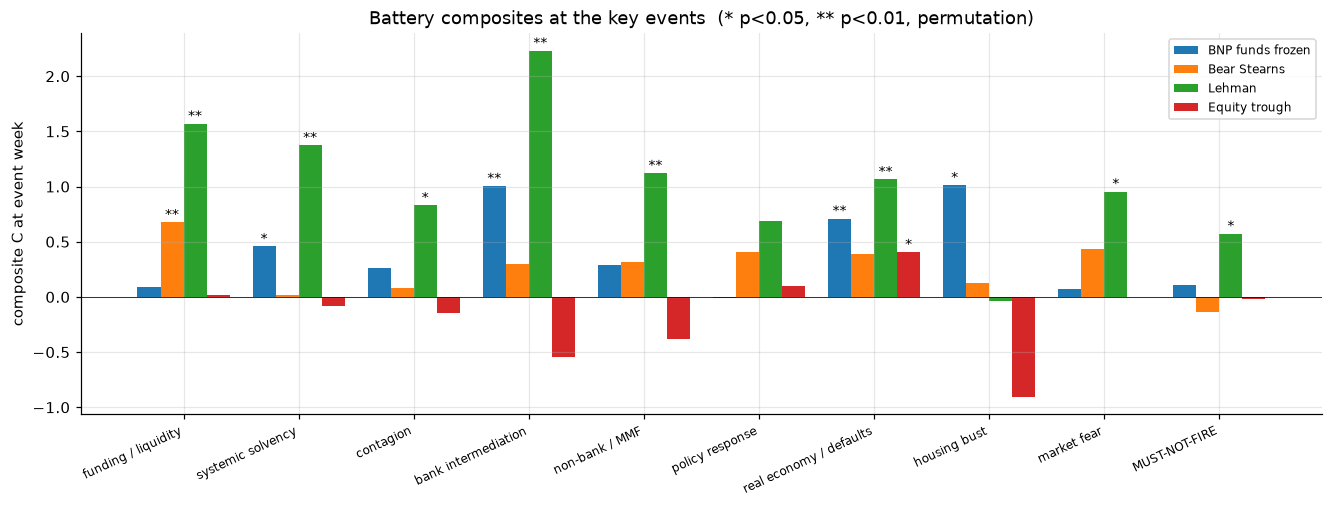

In [15]:
pz = ev_tab.filter(pl.col("event").is_in(list(KEY_EVENTS)))
fig, ax = plt.subplots(figsize=(12, 4.5))
evs = [e for e in KEY_EVENTS if e in pz["event"].unique().to_list()]
wbar = 0.8 / max(len(evs), 1)
for j, e in enumerate(evs):
    g = pz.filter(pl.col("event") == e).sort(pl.col("battery").replace_strict({b: i for i, b in enumerate(blist)}))
    xs_ = np.arange(len(blist)) + j * wbar
    ax.bar(xs_, g["C"], width=wbar, label=e)
    for x_, c_, p_ in zip(xs_, g["C"], g["perm_p"]):
        if p_ < 0.05:
            ax.text(x_, c_ + (0.03 if c_ >= 0 else -0.1), "*" if p_ >= 0.01 else "**", ha="center", fontsize=9)
ax.set_xticks(np.arange(len(blist)) + 0.4 - wbar / 2, blist, rotation=25, ha="right", fontsize=8)
ax.axhline(0, color="k", lw=0.5); ax.set_ylabel("composite C at event week")
ax.legend(fontsize=8); ax.set_title("Battery composites at the key events  (* p<0.05, ** p<0.01, permutation)")
plt.show()

## 6. Horizon term structure

Short horizons (1–12w) react to the news shock; long horizons (12–52w) measure the build-up of
the narrative relative to a year ago. The composite uses only H = {12, 26, 52}; the short
profile shows what it deliberately leaves out.

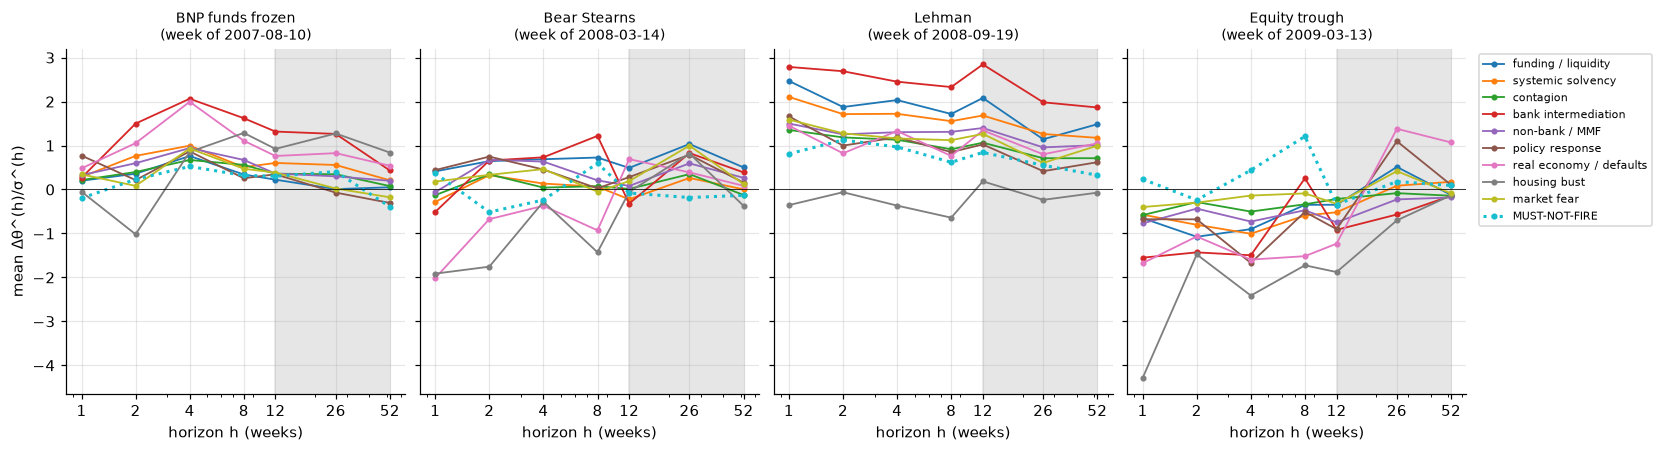

In [16]:
term = (panel.filter(pl.col(KEY).is_in([k for b in blist for k in BKEYS[b]]))
        .select("WEEK", KEY, *[f"Z{h}" for h in ALL_H]))
fig, axes = plt.subplots(1, len(KEY_EVENTS), figsize=(15, 4), sharey=True)
for ax, e in zip(axes, KEY_EVENTS):
    wk = wk_arr[event_week(EVENTS[e])]
    t = term.filter(pl.col("WEEK") == wk)
    for b in blist:
        g = t.filter(pl.col(KEY).is_in(BKEYS[b])).select([pl.col(f"Z{h}").mean() for h in ALL_H]).row(0)
        ax.plot(ALL_H, g, marker="o", ms=3, lw=1.2 if b != PLACEBO else 2,
                ls="-" if b != PLACEBO else ":", label=b)
    ax.axhline(0, color="k", lw=0.5); ax.set_xscale("log"); ax.set_xticks(ALL_H, [str(h) for h in ALL_H])
    ax.axvspan(min(COMPOSITE_H), max(COMPOSITE_H), color="0.9", zorder=0)
    ax.set_title(f"{e}\n(week of {wk})", fontsize=9); ax.set_xlabel("horizon h (weeks)")
axes[0].set_ylabel("mean Δθ^(h)/σ^(h)")
axes[-1].legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

## 7. Cross-section at Lehman

All 419 narrative keys ranked by composite in the Lehman week and at the post-Lehman peak
(mean over Sep-15 .. Oct-31 2008). Colour = reservoir. This is the unsupervised check: the
batteries are hand-picked, the top of this list is not.

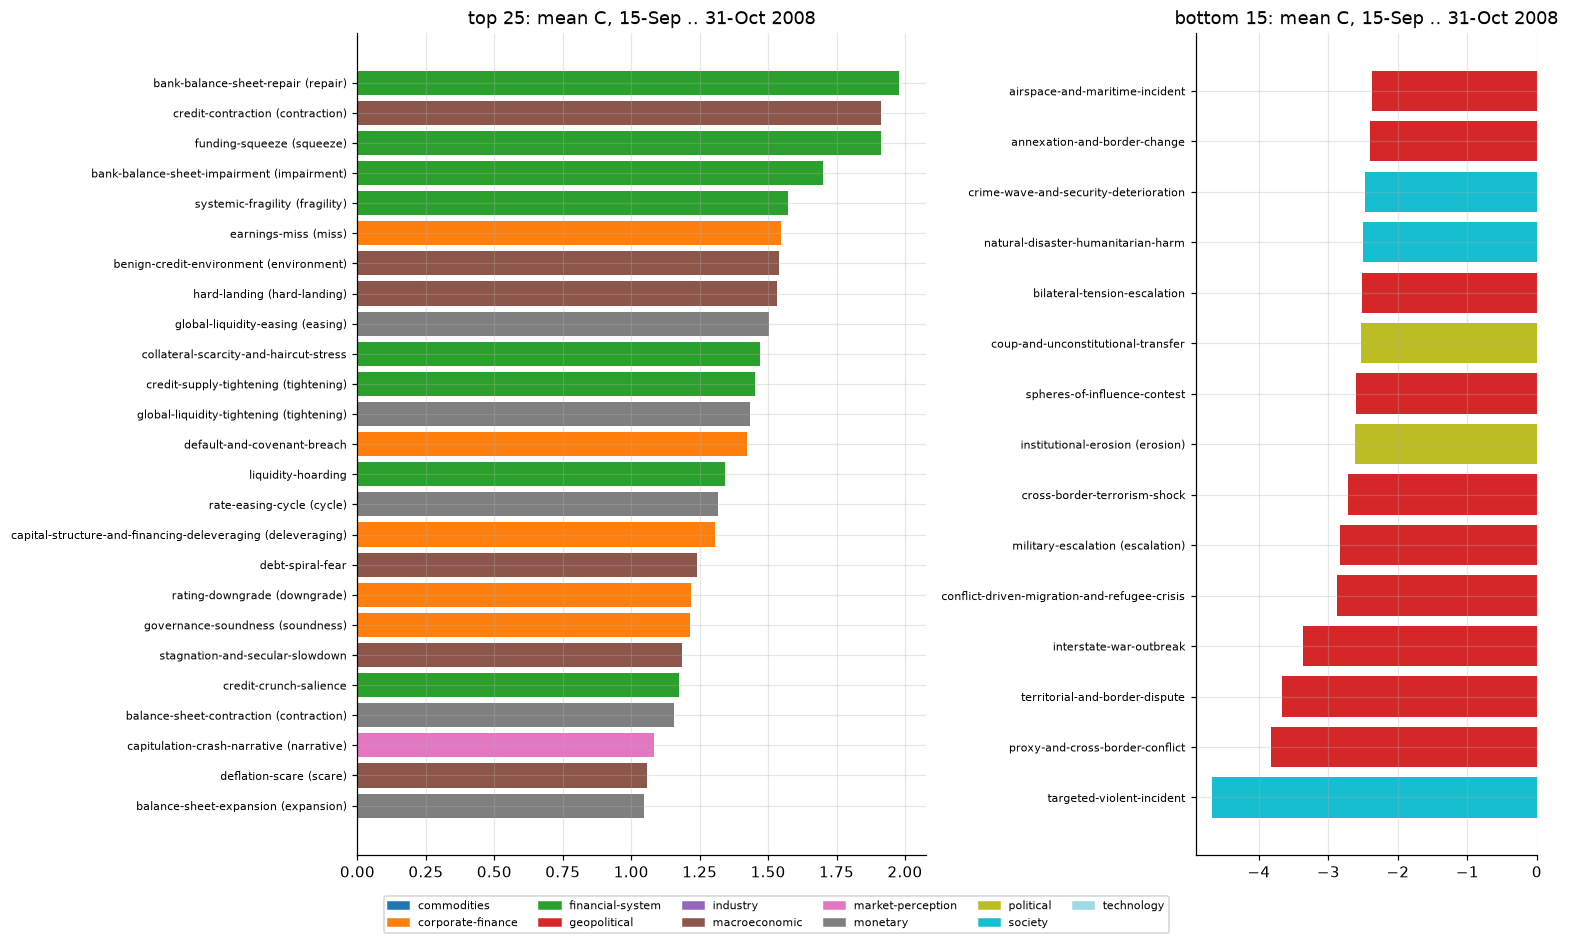

battery narratives among the top 25: 12 (expected by chance ≈ 2.3)


In [17]:
lw_ = (panel.filter(pl.col("WEEK").is_between(date(2008, 9, 15), date(2008, 10, 31)) & pl.col("COMPOSITE").is_not_null())
       .group_by(KEY).agg(pl.col("COMPOSITE").mean().alias("C_LEHMAN"))
       .join(NARR, on=KEY).sort("C_LEHMAN", descending=True))
top, bot = lw_.head(25), lw_.tail(15)
resv = sorted(NARR["reservoir"].unique().to_list())
cmap = dict(zip(resv, plt.cm.tab20(np.linspace(0, 1, len(resv)))))
fig, axes = plt.subplots(1, 2, figsize=(14, 8), width_ratios=[5, 3])
for ax, t, title in ((axes[0], top, "top 25"), (axes[1], bot, "bottom 15")):
    lab = [f"{r['narrative']} ({r['pole']})" if r["pole"] else r["narrative"] for r in t.iter_rows(named=True)]
    ax.barh(range(t.height), t["C_LEHMAN"], color=[cmap[r] for r in t["reservoir"]])
    ax.set_yticks(range(t.height), lab, fontsize=7); ax.invert_yaxis(); ax.set_title(f"{title}: mean C, 15-Sep .. 31-Oct 2008")
handles = [plt.Rectangle((0, 0), 1, 1, color=cmap[r]) for r in resv]
fig.legend(handles, resv, fontsize=7, loc="lower center", ncol=min(6, len(resv)), bbox_to_anchor=(0.5, -0.06))
plt.show()
in_b = {k for b in blist if b != PLACEBO for k in BKEYS[b]}
print(f"battery narratives among the top 25: {top.filter(pl.col(KEY).is_in(in_b)).height} "
      f"(expected by chance ≈ {25 * len(in_b) / lw_.height:.1f})")

## 8. Narrative waves: onset and peak timing

Onset = first week after 2007-01-01 in which the battery composite exceeds
`ONSET_THRESHOLD`; peak = arg-max over 2007–2009. The expected GFC ordering is housing →
funding / non-bank → systemic / contagion → policy → real economy / defaults.

battery,onset,peak,peak_C,weeks_lit
str,date,date,f64,i64
"""systemic solvency""",2008-09-19,2008-09-19,1.373944,4
"""contagion""",null,2008-09-19,0.829508,0
"""bank intermediation""",2007-08-03,2008-09-19,2.231506,15
"""non-bank / MMF""",2008-09-19,2008-09-19,1.121878,1
"""market fear""",null,2008-09-19,0.955025,0
"""funding / liquidity""",2008-03-21,2008-09-26,1.614005,8
"""MUST-NOT-FIRE""",null,2008-11-28,0.954507,0
"""policy response""",2008-10-10,2008-12-05,1.346908,6
"""real economy / defaults""",2007-08-17,2008-12-05,2.809892,21


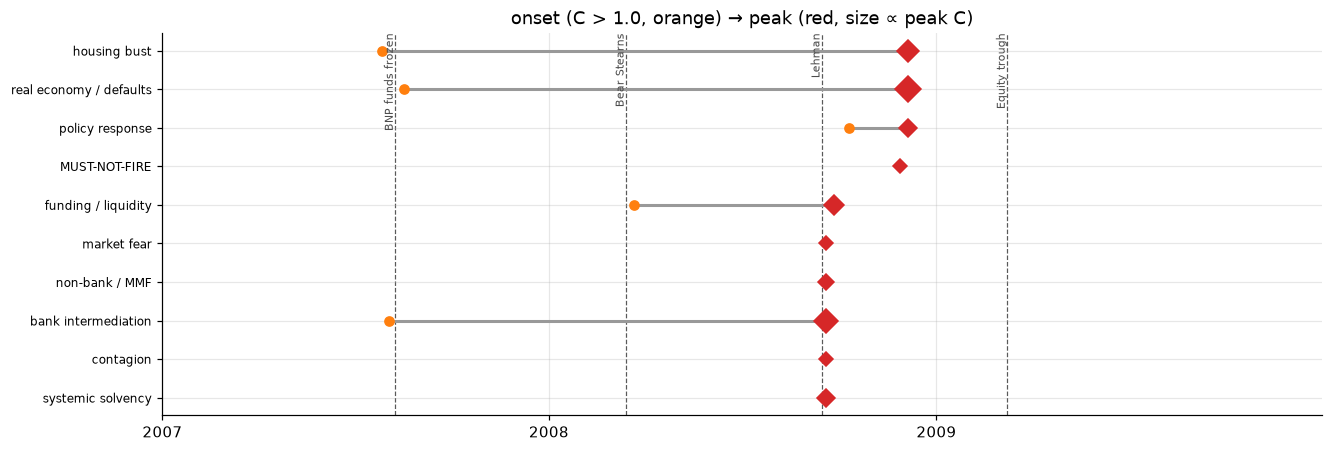

In [18]:
win = bat.filter(pl.col("WEEK").is_between(date(2007, 1, 1), date(2009, 12, 31)))
wv = []
for b in blist:
    y = win[b].to_numpy()
    on = np.flatnonzero(y > ONSET_THRESHOLD)
    wv.append({"battery": b, "onset": win["WEEK"][int(on[0])] if on.size else None,
               "peak": win["WEEK"][int(np.nanargmax(y))], "peak_C": float(np.nanmax(y)),
               "weeks_lit": int(on.size)})
waves = pl.DataFrame(wv).sort("peak")
display(waves)

fig, ax = plt.subplots(figsize=(12, 4))
for i, r in enumerate(waves.iter_rows(named=True)):
    if r["onset"] is not None:
        ax.plot([r["onset"], r["peak"]], [i, i], color="0.6", lw=2)
        ax.plot(r["onset"], i, "o", color="tab:orange")
    ax.plot(r["peak"], i, "D", color="tab:red", ms=4 + 3 * max(r["peak_C"], 0))
ax.set_yticks(range(waves.height), waves["battery"], fontsize=8)
date_axis(ax, date(2007, 1, 1), date(2009, 12, 31)); shade_events(ax)
ax.set_title(f"onset (C > {ONSET_THRESHOLD}, orange) → peak (red, size ∝ peak C)")
plt.show()

In [19]:
# the leading narratives of each quarter (mean composite), 2007Q1 .. 2009Q4
q = (panel.filter(pl.col("WEEK").is_between(date(2007, 1, 1), date(2009, 12, 31)) & pl.col("COMPOSITE").is_not_null())
     .with_columns(pl.col("WEEK").dt.truncate("1q").alias("Q"))
     .group_by("Q", KEY).agg(pl.col("COMPOSITE").mean())
     .join(NARR.select(KEY, "narrative", "pole"), on=KEY)
     .with_columns(pl.when(pl.col("pole").fill_null("") != "").then(pl.format("{} ({})", "narrative", "pole"))
                   .otherwise(pl.col("narrative")).alias("label"))
     .sort("Q", "COMPOSITE", descending=[False, True])
     .group_by("Q", maintain_order=True).head(5)
     .with_columns(pl.format("{} {}", pl.col("label"), pl.col("COMPOSITE").round(2)).alias("top"))
     .group_by("Q", maintain_order=True).agg(pl.col("top"))
     .with_columns(pl.col("Q").dt.strftime("%Y-%m"), *[pl.col("top").list.get(i).alias(f"#{i+1}") for i in range(5)])
     .drop("top"))
q

Q,#1,#2,#3,#4,#5
str,str,str,str,str,str
"""2007-01""","""targeted-violent-incident 4.15""","""proxy-and-cross-border-conflict 3.66""","""cross-border-terrorism-shock 3.05""","""territorial-and-border-dispute 2.47""","""natural-disaster-humanitarian-harm 2.41"""
"""2007-04""","""targeted-violent-incident 1.51""","""proxy-and-cross-border-conflict 1.14""","""cross-border-terrorism-shock 1.12""","""conflict-driven-migration-and-refugee-crisis 1.1""","""coup-and-unconstitutional-transfer 1.09"""
"""2007-07""","""earnings-beat (beat) 1.26""","""credit-contraction (contraction) 1.24""","""earnings-miss (miss) 1.14""","""metal-supply-expansion (expansion) 0.84""","""bank-balance-sheet-impairment (impairment) 0.83"""
"""2007-10""","""governance-soundness (soundness) 1.26""","""market-cap-milestone-and-disclosure 1.1""","""earnings-miss (miss) 1.09""","""bank-balance-sheet-impairment (impairment) 0.98""","""earnings-beat (beat) 0.92"""
"""2008-01""","""mandate-weakening (weakening) 2.02""","""mandate-strengthening (strengthening) 1.86""","""business-cycle-contraction (contraction) 1.63""","""stagnation-and-secular-slowdown 1.48""","""credit-contraction (contraction) 1.14"""
"""2008-04""","""earnings-miss (miss) 1.58""","""extraction-ramp-up (ramp-up) 1.39""","""productivity-slowdown (slowdown) 1.06""","""extraction-curtailment (curtailment) 0.8""","""business-cycle-contraction (contraction) 0.76"""
"""2008-07""","""hostile-and-contested-takeover 2.23""","""earnings-miss (miss) 1.92""","""governance-soundness (soundness) 1.56""","""penetration-milestone 1.55""","""product-launch 1.44"""
"""2008-10""","""business-cycle-contraction (contraction) 3.36""","""hard-landing (hard-landing) 2.45""","""stagnation-and-secular-slowdown 2.33""","""rate-easing-cycle (cycle) 2.06""","""deflation-scare (scare) 1.82"""
"""2009-01""","""fiscal-easing-decision (decision) 2.25""","""business-cycle-contraction (contraction) 2.15""","""fiscal-expansion-impulse (impulse) 1.87""","""stagnation-and-secular-slowdown 1.54""","""labour-market-slackening (slackening) 1.48"""


## 9. Robustness to stage 1 and placebo

Same pipeline with stage 1 switched off (weekly θ straight from raw attention). If the GFC
picture only exists with (or without) deseasonalisation, it is fragile. The must-not-fire
battery (booms / calm / tightening) is the placebo: it should not be lit during the crisis
and, if anything, should turn negative.

pooled corr(C, C without stage 1) = 0.811


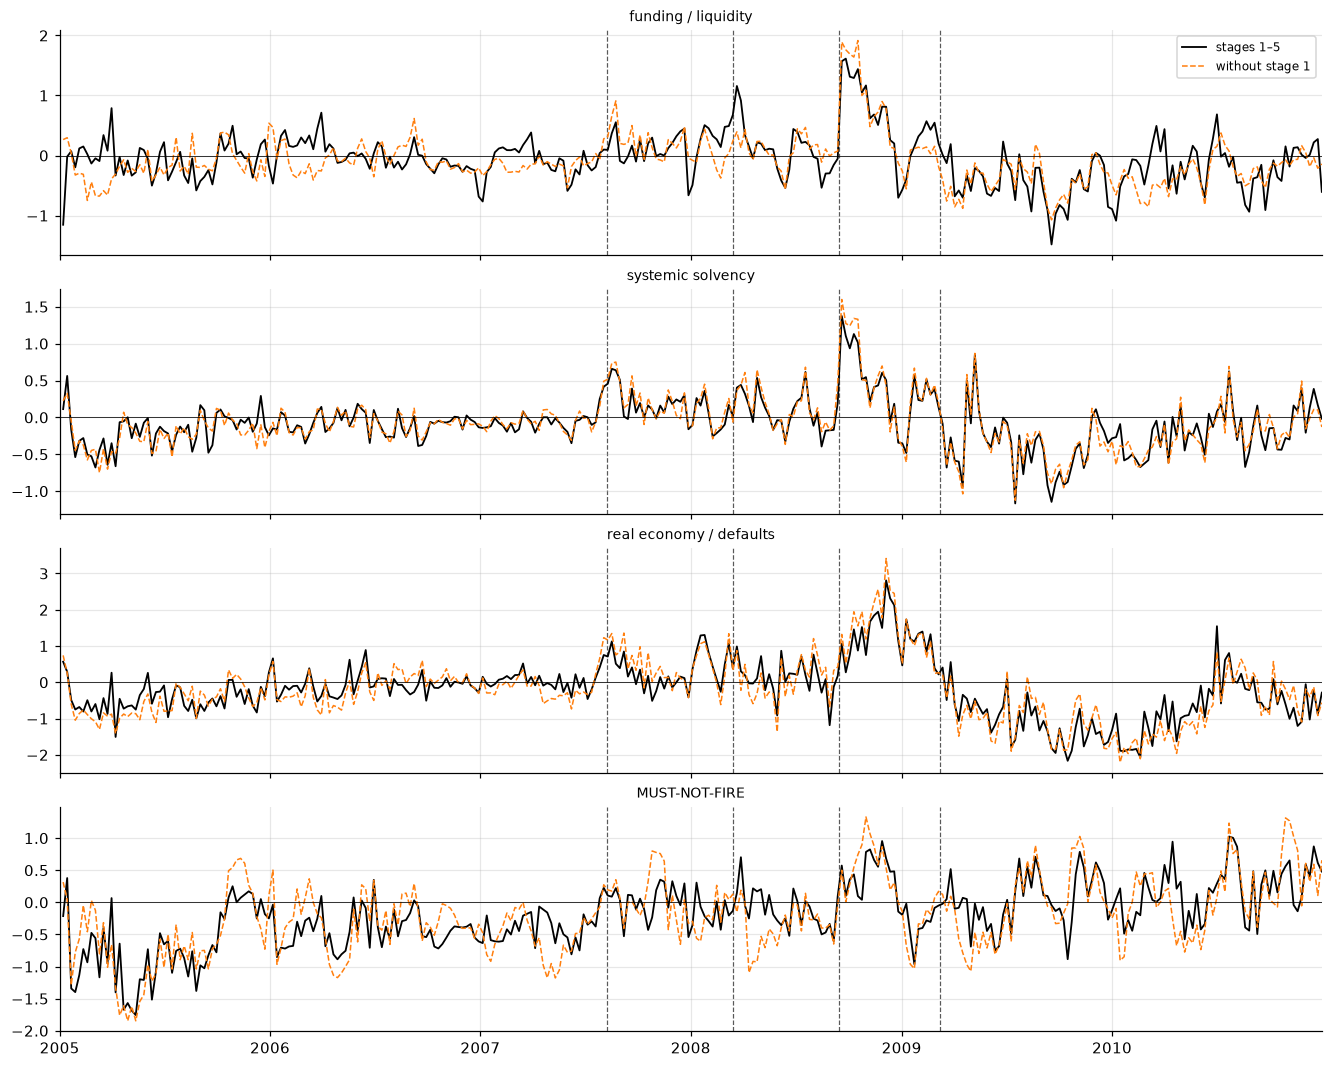

In [20]:
panel_raw = post_process(daily, deseason=False)
cmp_ = (panel.select("WEEK", KEY, "COMPOSITE")
        .join(panel_raw.select("WEEK", KEY, pl.col("COMPOSITE").alias("C_NODS")), on=["WEEK", KEY])
        .drop_nulls())
print(f"pooled corr(C, C without stage 1) = {np.corrcoef(cmp_['COMPOSITE'], cmp_['C_NODS'])[0, 1]:.3f}")
wide_raw = cmp_.pivot(on=KEY, index="WEEK", values="C_NODS").sort("WEEK").filter(pl.col("WEEK").is_between(*VIEW))

show = [b for b in ("funding / liquidity", "systemic solvency", "real economy / defaults", PLACEBO) if b in blist]
fig, axes = plt.subplots(len(show), 1, figsize=(12, 2.4 * len(show)), sharex=True)
for ax, b in zip(np.atleast_1d(axes), show):
    ks = [k for k in BKEYS[b] if k in wide_raw.columns]
    ax.plot(v["WEEK"], v[b], color="k", lw=1.2, label="stages 1–5")
    ax.plot(wide_raw["WEEK"], np.nanmean(wide_raw.select(ks).to_numpy(), axis=1), color="tab:orange",
            lw=1, ls="--", label="without stage 1")
    ax.axhline(0, color="k", lw=0.5); ax.set_title(b, fontsize=9); date_axis(ax); shade_events(ax, labels=False)
np.atleast_1d(axes)[0].legend(fontsize=8)
plt.show()

In [21]:
# placebo: share of crisis weeks in which each battery is above / below zero, vs the baseline
crisis = (date(2007, 8, 1), date(2009, 6, 30))
summ = []
for b in blist:
    cb, bb = bat.filter(pl.col("WEEK").is_between(*crisis))[b], bat.filter(pl.col("WEEK").is_between(*BASELINE))[b]
    summ.append({"battery": b, "mean_C_baseline": bb.mean(), "mean_C_crisis": cb.mean(),
                 "share_weeks_C>0_crisis": (cb > 0).mean(), "max_z_crisis": batz.filter(
                     pl.col("WEEK").is_between(*crisis))[b].max()})
pl.DataFrame(summ).with_columns(pl.selectors.float().round(2)).sort("mean_C_crisis", descending=True)

battery,mean_C_baseline,mean_C_crisis,share_weeks_C>0_crisis,max_z_crisis
str,f64,f64,f64,f64
"""real economy / defaults""",-0.12,0.37,0.69,6.96
"""bank intermediation""",-0.12,0.32,0.69,5.28
"""housing bust""",-0.07,0.17,0.59,3.32
"""funding / liquidity""",-0.06,0.16,0.61,5.97
"""systemic solvency""",-0.06,0.14,0.64,5.84
"""non-bank / MMF""",-0.05,0.08,0.6,5.63
"""policy response""",-0.13,0.06,0.49,3.99
"""contagion""",-0.11,0.02,0.52,3.55
"""market fear""",-0.1,-0.02,0.48,3.3


## 10. Reading guide / caveats

* **Attention, not tone.** θ measures how much of the flow is about a narrative, not whether
  the news is good or bad. Poles are separate series, so e.g. a "credit-boom" vs "credit-bust"
  contrast is visible only by comparing the two keys.
* **Composite scale.** Each horizon is rescaled by its week-*t* cross-sectional σ, so C is
  comparable across weeks in *relative* terms. The cross-sectional mean is kept (not
  demeaned), so a market-wide shift in what the news talks about is part of the signal.
* **Warm-up.** Stage 1 needs one prior year and the 52-week horizon a full year of changes:
  the composite starts roughly two years after the first scored month.
* **Point-in-time.** Every stage uses information available at the Friday of week *t*. The
  scores themselves are point-in-time (tau_asof, mu_asof with a 1-month delay).
* **Single configuration.** One scoring configuration (R2 / headline / max / q = 0.99); no
  bootstrap over headlines. The permutation test controls for market-wide moves within a week,
  not for serial correlation across weeks.